## Data exploration and profiling

This notebook aims to present the key findings from data cleaning and preliminary statistical studies performed using SQL, it also presents a more detailed statistical description of the data using histograms and boxplots. Finally, a study of the statistical behaviour oriented to failure is made.

### General description of data

In [1]:
import pandas as pd
from sqlalchemy import create_engine
from local_settings import postgres_url as url
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Load dataset to a pandas dataframe and show
url = f"postgresql+psycopg2://{url['pguser']}:{url['pgpassword']}@{url['pghost']}/{url['pgdb']}"
engine = create_engine(url)
df = pd.read_sql(f"SELECT * FROM milling_pdm_celsius",con=engine, index_col="register_id")
df


,product_id,product_type,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,tool_wear_failure,heat_dissipation_failure,power_failure,overstrain_failure,random_failure
register_id,,,,,,,,,,,,,
1,M14860,M,24.950006,35.450006,1551.0,42.8,0,False,False,False,False,False,False
2,L47181,L,25.050012,35.550012,1408.0,46.3,3,False,False,False,False,False,False
3,L47182,L,24.950006,35.350000,1498.0,49.4,5,False,False,False,False,False,False
4,L47183,L,25.050012,35.450006,1433.0,39.5,7,False,False,False,False,False,False
5,L47184,L,25.050012,35.550012,1408.0,40.0,9,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,M24855,M,25.649988,35.249994,1604.0,29.5,14,False,False,False,False,False,False
9997,H39410,H,25.749994,35.249994,1632.0,31.8,17,False,False,False,False,False,False
9998,M24857,M,25.850000,35.450006,1645.0,33.4,22,False,False,False,False,False,False


In [6]:
# Show all collumns in the database
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   register_id                  10000 non-null  int64  
 1   product_id                   10000 non-null  str    
 2   product_type                 10000 non-null  str    
 3   air_temperature_celsius      10000 non-null  float64
 4   process_temperature_celsius  10000 non-null  float64
 5   rotational_speed_rpm         10000 non-null  float64
 6   torque_nm                    10000 non-null  float64
 7   tool_wear_min                10000 non-null  int64  
 8   machine_failure              10000 non-null  bool   
 9   tool_wear_failure            10000 non-null  bool   
 10  heat_dissipation_failure     10000 non-null  bool   
 11  power_failure                10000 non-null  bool   
 12  overstrain_failure           10000 non-null  bool   
 13  random_failure              

### Data Quality Analysis (DQA)

### Summary of basic statistical metrics

In [8]:
df.describe()

,register_id,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,tool_wear_min
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,26.854930,36.855560,1538.776100,39.986910,107.951000
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147
min,1.00000,22.149988,32.550012,1168.000000,3.800000,0.000000
25%,2500.75000,25.149988,35.649988,1423.000000,33.200000,53.000000
50%,5000.50000,26.950006,36.950006,1503.000000,40.100000,108.000000
75%,7500.25000,28.350000,37.950006,1612.000000,46.800000,162.000000
max,10000.00000,31.350000,40.649988,2886.000000,76.600000,253.000000


### Raw numerical data boxplots

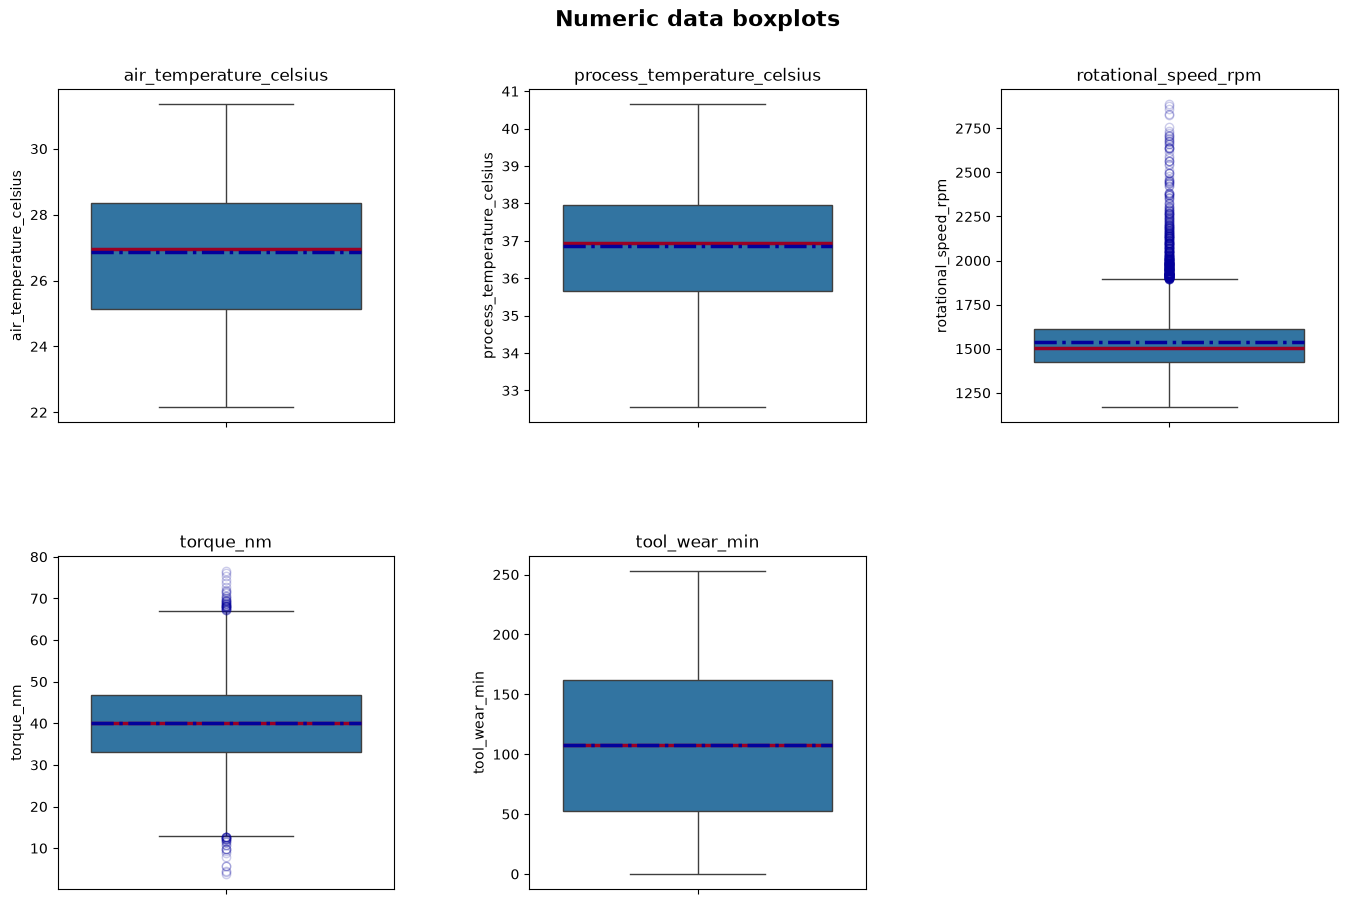

In [2]:
# Study of distributions of numerical data (boxplots)
layout = [
    ["air_temperature_celsius", "process_temperature_celsius", "rotational_speed_rpm"],
    ["torque_nm", "tool_wear_min", '.']
]
fig, ax_dict = plt.subplot_mosaic(layout, figsize=(16,10));
fig.suptitle('Numeric data boxplots', fontsize=16, fontweight='bold')
# Adjust spacing between plots and page margins
plt.subplots_adjust(
    left=0.1,      # Left margin (fraction of figure width)
    right=0.9,     # Right margin
    bottom=0.1,    # Bottom margin (fraction of figure height)
    top=0.9,       # Top margin
    wspace=0.4,    # Width padding between subplots (fraction of axes width)
    hspace=0.4     # Height padding between subplots (fraction of axes height)
)

for i, name in enumerate(ax_dict.keys(), 1):
    sns.boxplot(data=df,
                y=name,
                showmeans=True,
                meanline=True,
                #boxprops={"facecolor": "#9ED0FF"},
                medianprops={"color": "#9B0022", "linewidth": 2.5},
                meanprops={"color": "#03009B", "linewidth": 2.5, "linestyle": "-."},
                flierprops={"marker": "o", "markeredgecolor": "#03009B", "alpha": 0.2},
                ax=ax_dict[name])
    ax_dict[name].set_title(name)

# plt.savefig("boxplots.png")

### Raw numerical data distributions

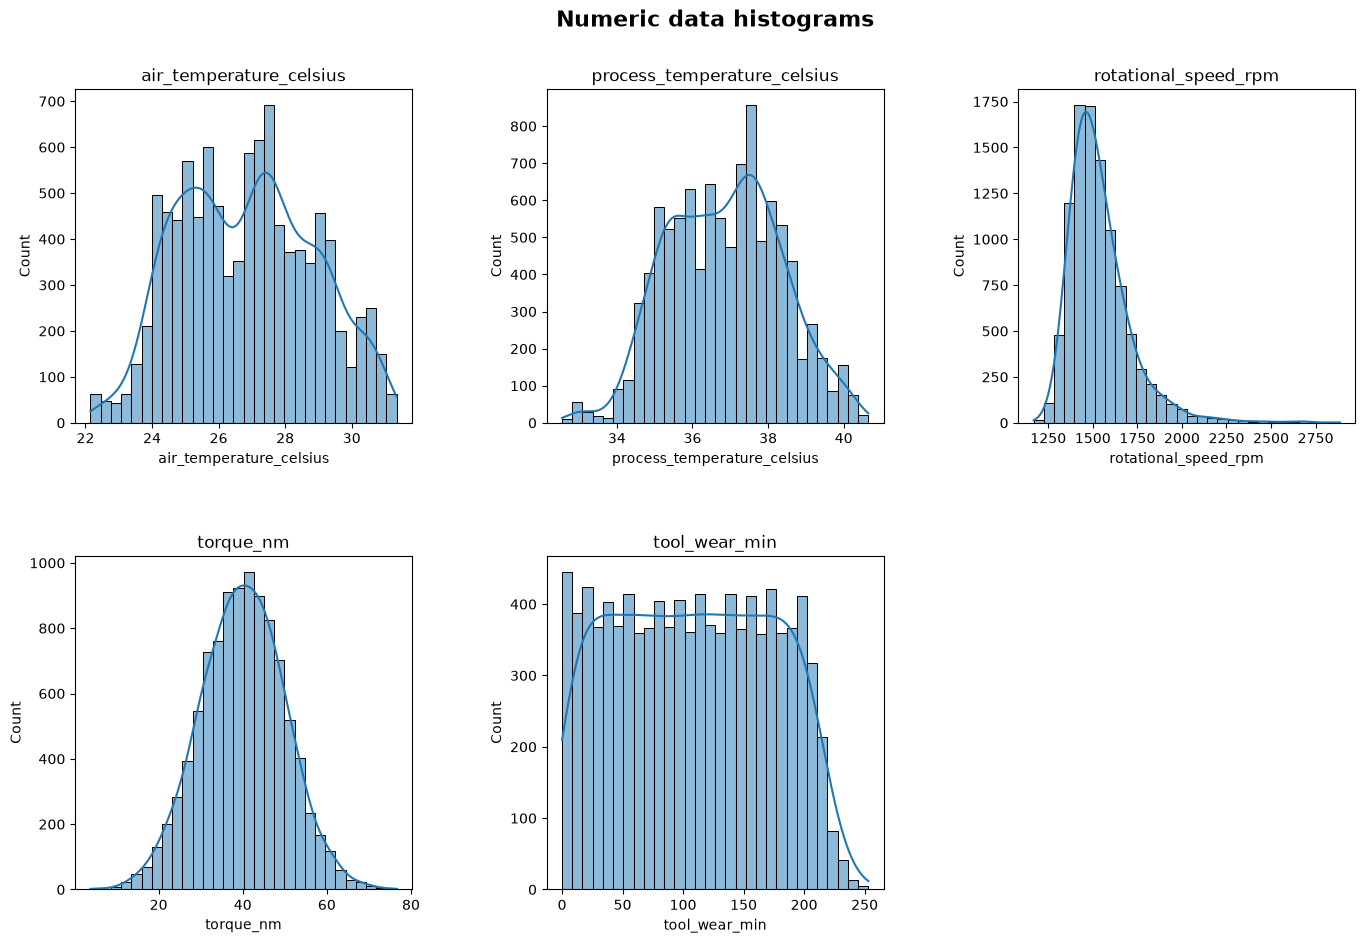

In [142]:
# Study of distributions of numerical data (histograms)

layout = [
    ["air_temperature_celsius", "process_temperature_celsius", "rotational_speed_rpm"],
    ["torque_nm", "tool_wear_min", '.']
]
fig, ax_dict = plt.subplot_mosaic(layout, figsize=(16,10));
fig.suptitle('Numeric data histograms', fontsize=16, fontweight='bold')

# Adjust spacing between plots and page margins
plt.subplots_adjust(
    left=0.1,      # Left margin (fraction of figure width)
    right=0.9,     # Right margin
    bottom=0.1,    # Bottom margin (fraction of figure height)
    top=0.9,       # Top margin
    wspace=0.4,    # Width padding between subplots (fraction of axes width)
    hspace=0.4     # Height padding between subplots (fraction of axes height)
)

for i, name in enumerate(ax_dict.keys(), 1):
    sns.histplot(data=df,
                #stat="density",
                #common_norm=False,
                x=name,
                #hue="machine_failure",
                bins = 30,
                kde=True,
                kde_kws={"bw_adjust":1.5},
                ax=ax_dict[name])
    ax_dict[name].set_title(name)

plt.savefig("histplots.png")

### Statistical behaviour under failure

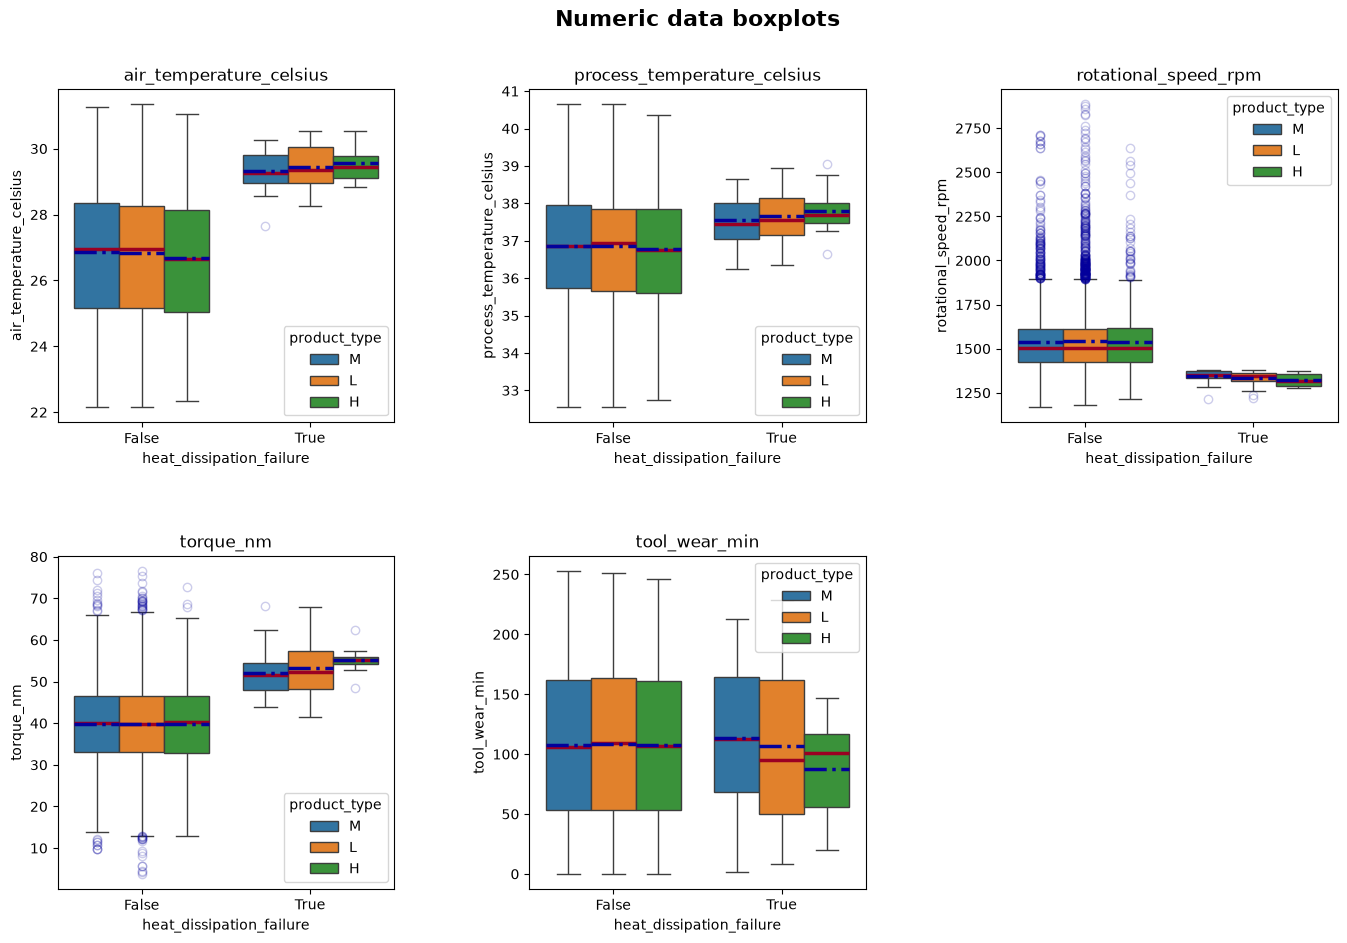

In [ ]:
# Study of distributions of numerical data (boxplots)
layout = [
    ["air_temperature_celsius", "process_temperature_celsius", "rotational_speed_rpm"],
    ["torque_nm", "tool_wear_min", '.']
]
fig, ax_dict = plt.subplot_mosaic(layout, figsize=(16,10));
fig.suptitle('Numeric data boxplots', fontsize=16, fontweight='bold')
# Adjust spacing between plots and page margins
plt.subplots_adjust(
    left=0.1,      # Left margin (fraction of figure width)
    right=0.9,     # Right margin
    bottom=0.1,    # Bottom margin (fraction of figure height)
    top=0.9,       # Top margin
    wspace=0.4,    # Width padding between subplots (fraction of axes width)
    hspace=0.4     # Height padding between subplots (fraction of axes height)
)

for i, name in enumerate(ax_dict.keys(), 1):
    sns.boxplot(data=df,
                y=name,
                x='heat_dissipation_failure',
                hue="product_type",
                showmeans=True,
                meanline=True,
                #boxprops={"facecolor": "#9ED0FF"},
                medianprops={"color": "#9B0022", "linewidth": 2.5},
                meanprops={"color": "#03009B", "linewidth": 2.5, "linestyle": "-."},
                flierprops={"marker": "o", "markeredgecolor": "#03009B", "alpha": 0.2},
                ax=ax_dict[name])
    ax_dict[name].set_title(name)

# plt.savefig("boxplots.png")